# Exploring the Walrus model: architecture, config, and dimensions

Everything here only instantiates `nn.Module` graphs from config with no
data loading, GPU, or premade checkpoints.

In [1]:
import os
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate

warnings.filterwarnings("ignore")  # a couple of harmless upstream deprecation warnings

# Assumes this notebook is run from demo_notebooks/, as in walrus_example_1_RunningWalrus.ipynb
CONFIG_DIR = os.path.abspath("../walrus/configs")
assert os.path.isdir(CONFIG_DIR), f"Couldn't find {CONFIG_DIR} - run this notebook from demo_notebooks/"


def count_params(module):
    return sum(p.numel() for p in module.parameters())


def build_model(overrides, n_states=67):
    '''Compose the Hydra config for walrus/configs/config.yaml with the given model.*
    overrides and instantiate the resulting IsotropicModel.

    n_states defaults to 67, the number of physical fields in the full pretraining
    mixture (see the field_index_map printed in walrus_example_1_RunningWalrus.ipynb)
    it only sizes the encoder/decoder's input projection, not the bulk of the model.
    '''
    with initialize_config_dir(version_base=None, config_dir=CONFIG_DIR):
        cfg = compose(
            config_name="config",
            overrides=["server=leonardo", "data=available_leonardo"] + overrides,
        )
    return instantiate(cfg.model, n_states=n_states)


def component_breakdown(model):
    encoder = sum(count_params(m) for m in model.embed.values())
    processor = sum(count_params(b) for b in model.blocks)
    decoder = sum(count_params(m) for m in model.debed.values())
    return {
        "encoder": encoder,
        "processor": processor,
        "decoder": decoder,
        "total": encoder + processor + decoder,
    }


def millions(n):
    return n / 1e6


/scratch_local/ipykernel_1830324/2787913375.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## The config hierarchy

Walrus's model is entirely config-driven through Hydra. `configs/config.yaml` picks
`model: isotropic_model` by default, and `configs/model/isotropic_model.yaml` sets the base
architecture defaults (before any command-line overrides from a run script):

In [2]:
with open(os.path.join(CONFIG_DIR, "model", "isotropic_model.yaml")) as f:
    print(f.read())

defaults:
  - encoder: spacebag_and_vstride_encoder
  - decoder: vstride_decoder
  - processor: space_time_split
  - norm_layer: rmsgroupnorm
_target_: walrus.models.IsotropicModel
hidden_dim: 768
projection_dim: 96
intermediate_dim: 192 #
processor_blocks: 12
drop_path: .05
groups: 12
max_d: 3
causal_in_time: False
include_d: [2, 3]
override_dimensionality: 3 # Force it to treat all data as 3D
jitter_patches: True
gradient_checkpointing_freq: 0



`IsotropicModel` (defined in
[`walrus/models/isotropic_model.py`](../walrus/models/isotropic_model.py)) wires together three
Hydra-instantiated pieces:

- **`encoder`** — one `hMLP`/`vstride`-style encoder per spatial dimensionality in `include_d`
  (a `nn.ModuleDict` keyed `"2"`, `"3"`, ...), projecting the raw fields up to `hidden_dim`
  through an `intermediate_dim`-wide hidden layer.
- **`processor`** — `processor_blocks` repeated blocks (by default
  `SpaceTimeSplitBlock`s doing factorized space + time attention; the run scripts swap the
  space-mixing sub-block to `full_spatial_attention`), each operating at `hidden_dim`.
- **`decoder`** — the mirror image of the encoder, `hidden_dim` back down to the number of
  physical fields (`n_states`).

`n_states` and `intermediate_dim` size the encoder/decoder; `hidden_dim`, `processor_blocks`,
and the space-mixing block's `mlp_dim` size the processor — and as we'll see below, the
processor is where almost all of the parameters live, which is why those three are exactly the
axes `gen_star_search_runs.py` sweeps. `groups` and `projection_dim` also live on the
encoder/decoder side of the config but, as section 6 shows by actually sweeping them, don't
size anything at all: `groups` only controls how `RMSGroupNorm` groups channels for its
normalization statistics (its affine weight/bias are shaped by channel count, not group count),
and `projection_dim` is only routed to the patch jitterer's `stage_dim` — the jitterer class
`IsotropicModel` actually instantiates (`PatchJittererBoundaryPad`) stores that value but never
turns it into a learnable parameter.

## 2. The original, unmodified Walrus

These are the exact `model.*` overrides from
[`walrus/run_scripts/pretrain_example_distributed_walrus.sh`](../walrus/run_scripts/pretrain_example_distributed_walrus.sh)
and [`LeonardoRunScripts/full_dimension_run.sh`](../LeonardoRunScripts/full_dimension_run.sh) —
the paper-scale architecture, not the smaller anchor the dimension sweep varies around.

In [3]:
PAPER_SCALE_OVERRIDES = [
    "model/processor/space_mixing=full_spatial_attention",
    "model.projection_dim=48",
    "model.intermediate_dim=352",
    "model.hidden_dim=1408",
    "model.groups=16",
    "model.processor_blocks=40",
    "model.drop_path=0.05",
    "model.processor.space_mixing.num_heads=16",
    "model.processor.time_mixing.num_heads=16",
    "model.causal_in_time=True",
    "model.override_dimensionality=0",
]

paper_model = build_model(PAPER_SCALE_OVERRIDES)
paper_stats = component_breakdown(paper_model)

print(paper_model)

IsotropicModel(
  (patch_jitterer): PatchJittererBoundaryPad()
  (embed): ModuleDict(
    (2): SpaceBagAdaptiveDVstrideEncoder(
      (proj1): Conv3d(67, 352, kernel_size=(8, 8, 8), stride=(1, 1, 1), bias=False)
      (norm1): RMSGroupNorm(16, 352, eps=1e-06, affine=True)
      (act): SiLU()
      (proj2): Conv3d(352, 1408, kernel_size=(4, 4, 4), stride=(1, 1, 1), bias=False)
      (norm2): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    )
    (3): SpaceBagAdaptiveDVstrideEncoder(
      (proj1): Conv3d(67, 352, kernel_size=(8, 8, 8), stride=(1, 1, 1), bias=False)
      (norm1): RMSGroupNorm(16, 352, eps=1e-06, affine=True)
      (act): SiLU()
      (proj2): Conv3d(352, 1408, kernel_size=(4, 4, 4), stride=(1, 1, 1), bias=False)
      (norm2): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    )
  )
  (blocks): ModuleList(
    (0): SpaceTimeSplitBlock(
      (space_mixing): FullAttention(
        (norm1): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
        (fused_ff_qkv): Linear(in

In [4]:
for name, n in paper_stats.items():
    print(f"{name:>10s}: {millions(n):>9.1f}M params ({n / paper_stats['total']:>5.1%} of total)" if name != "total"
          else f"{name:>10s}: {millions(n):>9.1f}M params")

   encoder:      87.6M params ( 6.8% of total)
 processor:    1111.0M params (86.4% of total)
   decoder:      87.6M params ( 6.8% of total)
     total:    1286.2M params


~1.29B parameters, in line with the "1.3B parameter model" described in
`walrus_example_1_RunningWalrus.ipynb`. Notice how lopsided the split is: the processor alone
holds roughly six-sevenths of the model. That's the direct consequence of `full_spatial_attention`
scaling like a standard transformer block (`hidden_dim` for the QKV/output projections, plus an
`mlp_dim`-wide feed-forward — `hidden_dim * 4` by default) repeated `processor_blocks` times,
versus the encoder/decoder only appearing once each.

## 3. The scaling-sweep anchor, for comparison

[`LeonardoRunScripts/gen_star_search_runs.py`](../LeonardoRunScripts/gen_star_search_runs.py) sweeps a
much smaller architecture, sized to fit a single Leonardo node (4x A100) rather than the
24-node/HSDP job the paper-scale model was pretrained with:

In [5]:
ANCHOR = {"hidden_dim": 768, "depth": 12, "mlp": 2048}
HEADS = 16


def anchor_overrides(hidden_dim, depth, mlp):
    return [
        "model/processor/space_mixing=full_spatial_attention",
        "model.projection_dim=48",
        "model.intermediate_dim=352",
        f"model.hidden_dim={hidden_dim}",
        "model.groups=16",
        f"model.processor_blocks={depth}",
        "model.drop_path=0.1",
        f"model.processor.space_mixing.mlp_dim={mlp}",
        f"model.processor.space_mixing.num_heads={HEADS}",
        f"model.processor.time_mixing.num_heads={HEADS}",
        "model.causal_in_time=True",
        "model.jitter_patches=True",
        "model.override_dimensionality=0",
    ]


anchor_model = build_model(anchor_overrides(**ANCHOR))
anchor_stats = component_breakdown(anchor_model)

print(f"Anchor total:      {millions(anchor_stats['total']):>7.1f}M params")
print(f"Paper-scale total:  {millions(paper_stats['total']):>7.1f}M params")
print(f"Ratio:              {paper_stats['total'] / anchor_stats['total']:>7.1f}x")

Anchor total:        202.6M params
Paper-scale total:   1286.2M params
Ratio:                  6.3x


The sweep anchor is about 6.3x smaller than the real Walrus — deliberately, so a full one-node
sweep is affordable, while still using the same block type (`full_spatial_attention`) and the
same encoder/decoder settings (`projection_dim`, `intermediate_dim`, `groups`).

## 4. How each swept axis moves the parameter count

Same axis/option lists as `gen_star_search_runs.py`'s `options` dict — hold the other two axes at
their anchor value, vary one at a time.

In [6]:
OPTIONS = {
    "hidden_dim": [384, 512, 640, 768, 896, 1024],
    "depth": [6, 8, 10, 12, 14, 16],
    "mlp": [1024, 1536, 2048, 2560, 3072],
}

rows = []
for axis, values in OPTIONS.items():
    combo = dict(ANCHOR)
    for value in values:
        combo[axis] = value
        model = build_model(anchor_overrides(**combo))
        rows.append({"axis": axis, "value": value, **component_breakdown(model)})
    combo = dict(ANCHOR)

sweep_df = pd.DataFrame(rows)
sweep_df

,axis,value,encoder,processor,decoder,total
0,hidden_dim,384,41452992,28390656,41452358,111296006
1,hidden_dim,512,47220416,44135424,47219526,138575366
2,hidden_dim,640,52987840,63025920,52986694,169000454
3,hidden_dim,768,58755264,85062144,58753862,202571270
4,hidden_dim,896,64522688,110244096,64521030,239287814
5,hidden_dim,1024,70290112,138571776,70288198,279150086
6,depth,6,58755264,42531072,58753862,160040198
7,depth,8,58755264,56708096,58753862,174217222
8,depth,10,58755264,70885120,58753862,188394246
9,depth,12,58755264,85062144,58753862,202571270


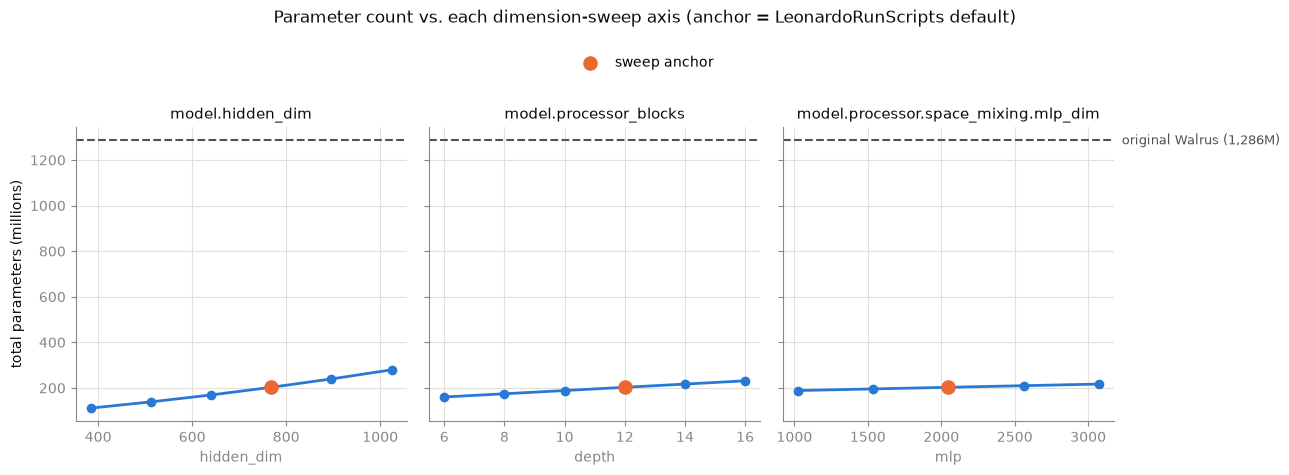

In [7]:
AXIS_LABELS = {
    "hidden_dim": "model.hidden_dim",
    "depth": "model.processor_blocks",
    "mlp": "model.processor.space_mixing.mlp_dim",
}

# Colors follow the project's categorical palette: one hue (blue) for the swept metric
# since all three panels encode the same quantity (total params), distinguished by
# panel title rather than color; chart chrome (grid/ink) from the same reference palette.
SERIES_COLOR = "#2a78d6"
ANCHOR_MARKER_COLOR = "#eb6834"
REFERENCE_COLOR = "#52514e"
GRIDLINE_COLOR = "#e1e0d9"
INK = "#0b0b0b"
MUTED = "#898781"

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
paper_total_m = millions(paper_stats["total"])

for ax, (axis, values) in zip(axes, OPTIONS.items()):
    sub = sweep_df[sweep_df["axis"] == axis].sort_values("value")
    ax.plot(
        sub["value"], sub["total"].apply(millions),
        color=SERIES_COLOR, linewidth=2, marker="o", markersize=6, zorder=3,
    )
    anchor_value = ANCHOR[axis]
    anchor_row = sub[sub["value"] == anchor_value].iloc[0]
    ax.scatter(
        [anchor_value], [millions(anchor_row["total"])],
        color=ANCHOR_MARKER_COLOR, s=90, zorder=4, label="sweep anchor",
    )
    ax.axhline(
        paper_total_m, color=REFERENCE_COLOR, linewidth=1.5, linestyle="--", zorder=2,
    )
    ax.set_title(AXIS_LABELS[axis], color=INK, fontsize=11)
    ax.set_xlabel(axis, color=MUTED)
    ax.grid(True, color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_ylabel("total parameters (millions)", color=INK)
axes[-1].text(
    axes[-1].get_xlim()[1], paper_total_m, f"  original Walrus ({paper_total_m:,.0f}M)",
    color=REFERENCE_COLOR, va="center", fontsize=9,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle(
    "Parameter count vs. each dimension-sweep axis (anchor = LeonardoRunScripts default)",
    color=INK, fontsize=12, y=1.12,
)
fig.tight_layout()
plt.show()

## 5. Component breakdown across the sweep

The line plot above only shows *total* parameters. Splitting each bar into encoder /
processor / decoder shows *why* the three axes behave differently: `hidden_dim` and
`processor_blocks` grow the processor segment while the encoder/decoder segments stay flat
(neither axis touches them), and `mlp_dim` grows the processor segment more slowly still,
since it only widens the feed-forward inside each block. The reference split in the title is
the full paper-scale model from section 2 (`paper_stats`, already built — no extra model
builds needed here) — at that scale the processor is an even larger ~86% of the total.

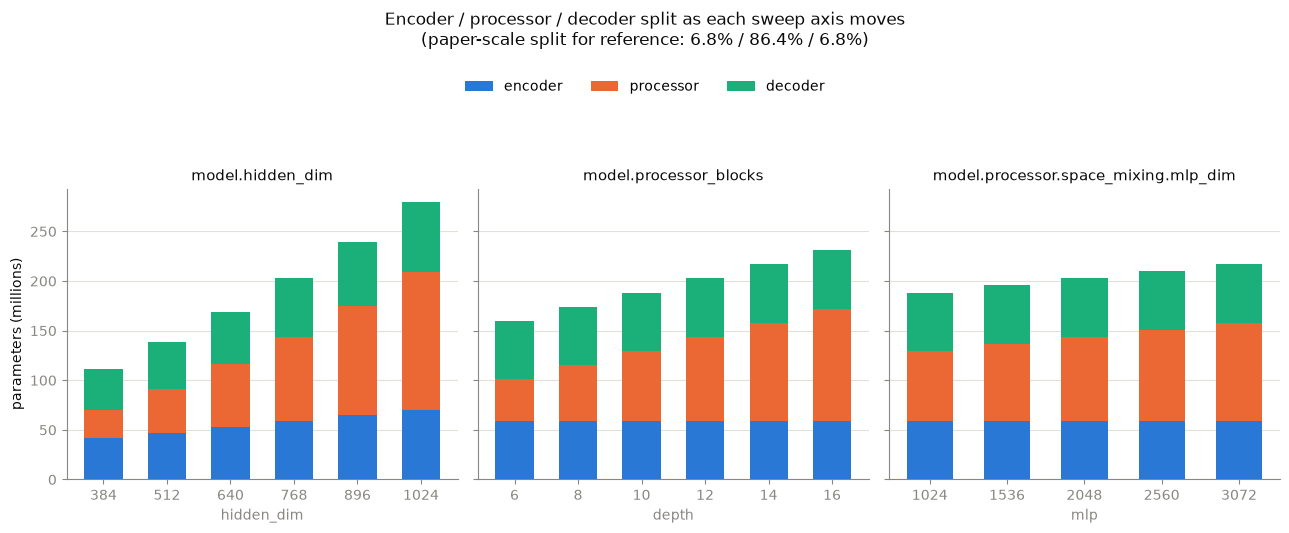

In [8]:
COMPONENT_COLORS = {"encoder": "#2a78d6", "processor": "#eb6834", "decoder": "#1baf7a"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)

for ax, (axis, values) in zip(axes, OPTIONS.items()):
    sub = sweep_df[sweep_df["axis"] == axis].sort_values("value")
    x = range(len(sub))
    bottom = [0.0] * len(sub)
    for component in ["encoder", "processor", "decoder"]:
        heights = sub[component].apply(millions).to_numpy()
        ax.bar(
            x, heights, bottom=bottom, width=0.6,
            color=COMPONENT_COLORS[component], label=component, zorder=3,
        )
        bottom = [b + h for b, h in zip(bottom, heights)]
    ax.set_xticks(list(x))
    ax.set_xticklabels(sub["value"], color=MUTED)
    ax.set_title(AXIS_LABELS[axis], color=INK, fontsize=11)
    ax.set_xlabel(axis, color=MUTED)
    ax.grid(True, axis="y", color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_ylabel("parameters (millions)", color=INK)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.07))
fig.suptitle(
    "Encoder / processor / decoder split as each sweep axis moves\n"
    f"(paper-scale split for reference: "
    f"{paper_stats['encoder'] / paper_stats['total']:.1%} / "
    f"{paper_stats['processor'] / paper_stats['total']:.1%} / "
    f"{paper_stats['decoder'] / paper_stats['total']:.1%})",
    color=INK, fontsize=12, y=1.2,
)
fig.tight_layout()
plt.show()

## 6. The axes the sweep skips: encoder/decoder-only dials

Section 1 named `groups`, `projection_dim`, and `intermediate_dim` as encoder/decoder-side
knobs, plus the attention head counts (`processor.space_mixing.num_heads` /
`processor.time_mixing.num_heads`). Here we actually sweep all four, one at a time, around the
same sweep anchor (`hidden_dim`/`processor_blocks`/`mlp_dim` held fixed). `groups` norms both
of the encoder's stages (at `intermediate_dim=352` and `hidden_dim=768`), so its swept values
must divide both evenly; `heads` only has to divide `hidden_dim=768`. The result is sharper than
"these move total params far less than `hidden_dim` or `processor_blocks`": two of the four turn
out to move it *not at all*.

In [9]:
COMPONENT_ANCHOR = {"projection_dim": 48, "intermediate_dim": 352, "groups": 16, "heads": 16}
COMPONENT_OPTIONS = {
    "projection_dim": [16, 32, 48, 64, 96, 128],
    "intermediate_dim": [128, 192, 256, 352, 512, 704],
    "groups": [4, 8, 16, 32],
    "heads": [4, 8, 16, 24, 32],
}


def component_axis_overrides(projection_dim, intermediate_dim, groups, heads):
    return [
        "model/processor/space_mixing=full_spatial_attention",
        f"model.projection_dim={projection_dim}",
        f"model.intermediate_dim={intermediate_dim}",
        f"model.hidden_dim={ANCHOR['hidden_dim']}",
        f"model.groups={groups}",
        f"model.processor_blocks={ANCHOR['depth']}",
        "model.drop_path=0.1",
        f"model.processor.space_mixing.mlp_dim={ANCHOR['mlp']}",
        f"model.processor.space_mixing.num_heads={heads}",
        f"model.processor.time_mixing.num_heads={heads}",
        "model.causal_in_time=True",
        "model.jitter_patches=True",
        "model.override_dimensionality=0",
    ]


rows2 = []
for axis, values in COMPONENT_OPTIONS.items():
    combo = dict(COMPONENT_ANCHOR)
    for value in values:
        combo[axis] = value
        model = build_model(component_axis_overrides(**combo))
        rows2.append({"axis": axis, "value": value, **component_breakdown(model)})
    combo = dict(COMPONENT_ANCHOR)

component_sweep_df = pd.DataFrame(rows2)
component_sweep_df

,axis,value,encoder,processor,decoder,total
0,projection_dim,16,58755264,85062144,58753862,202571270
1,projection_dim,32,58755264,85062144,58753862,202571270
2,projection_dim,48,58755264,85062144,58753862,202571270
3,projection_dim,64,58755264,85062144,58753862,202571270
4,projection_dim,96,58755264,85062144,58753862,202571270
5,projection_dim,128,58755264,85062144,58753862,202571270
6,intermediate_dim,128,21366528,85062144,21365126,127793798
7,intermediate_dim,192,32049024,85062144,32047622,149158790
8,intermediate_dim,256,42731520,85062144,42730118,170523782
9,intermediate_dim,352,58755264,85062144,58753862,202571270


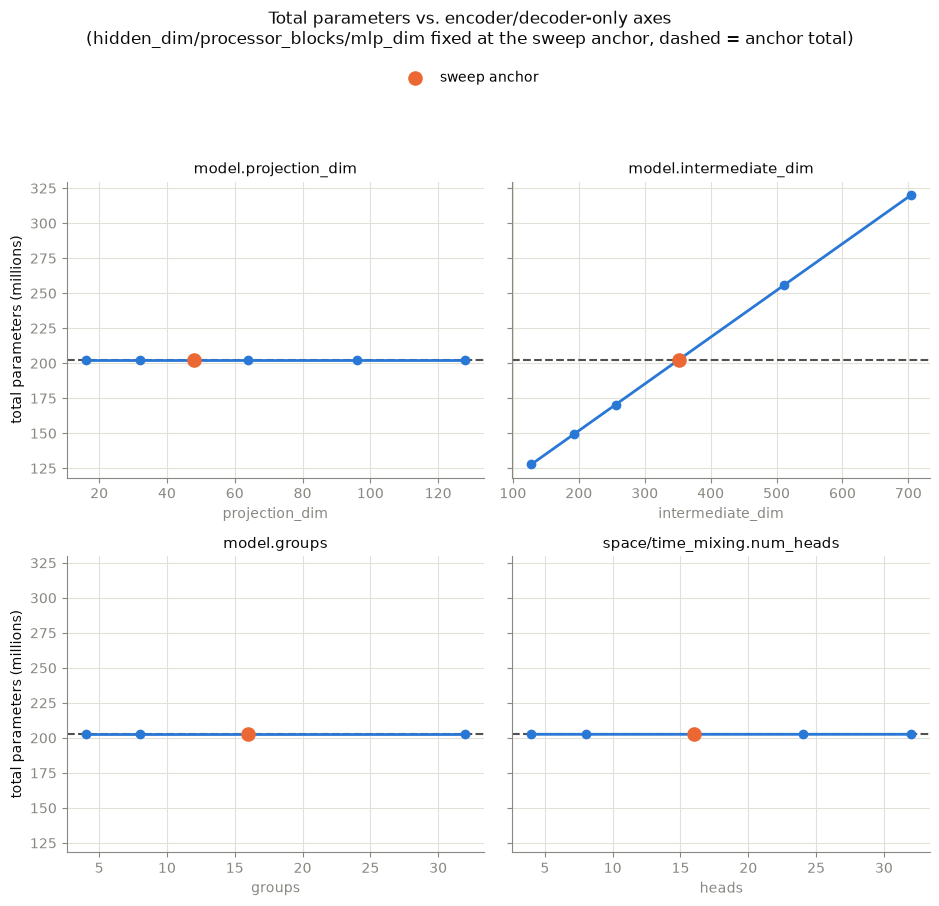

In [10]:
COMPONENT_AXIS_LABELS = {
    "projection_dim": "model.projection_dim",
    "intermediate_dim": "model.intermediate_dim",
    "groups": "model.groups",
    "heads": "space/time_mixing.num_heads",
}

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.2), sharey=True)
anchor_total_m = millions(anchor_stats["total"])

for ax, (axis, values) in zip(axes.flat, COMPONENT_OPTIONS.items()):
    sub = component_sweep_df[component_sweep_df["axis"] == axis].sort_values("value")
    ax.plot(
        sub["value"], sub["total"].apply(millions),
        color=SERIES_COLOR, linewidth=2, marker="o", markersize=6, zorder=3,
    )
    anchor_value = COMPONENT_ANCHOR[axis]
    anchor_row = sub[sub["value"] == anchor_value].iloc[0]
    ax.scatter(
        [anchor_value], [millions(anchor_row["total"])],
        color=ANCHOR_MARKER_COLOR, s=90, zorder=4, label="sweep anchor",
    )
    ax.axhline(anchor_total_m, color=REFERENCE_COLOR, linewidth=1.5, linestyle="--", zorder=2)
    ax.set_title(COMPONENT_AXIS_LABELS[axis], color=INK, fontsize=11)
    ax.set_xlabel(axis, color=MUTED)
    ax.grid(True, color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

for ax in axes[:, 0]:
    ax.set_ylabel("total parameters (millions)", color=INK)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle(
    "Total parameters vs. encoder/decoder-only axes\n"
    "(hidden_dim/processor_blocks/mlp_dim fixed at the sweep anchor, dashed = anchor total)",
    color=INK, fontsize=12, y=1.1,
)
fig.tight_layout()
plt.show()

`component_sweep_df` makes it exact: total parameter count is **bit-for-bit identical across
every swept value** of `groups` and `projection_dim` (202,571,270 always), moves only ~9K params
(~0.005%) across the full `heads` range, and only `intermediate_dim` produces a real change
(127.8M–320.1M). Checking the source confirms this isn't noise:

- **`groups`** — `RMSGroupNorm`'s affine weight/bias are shaped by `num_channels`
  ([`walrus/models/shared_utils/normalization.py:83`](../walrus/models/shared_utils/normalization.py)),
  not `num_groups`; the group count is only used at `forward()` time to reshape activations for
  computing normalization statistics. It literally cannot change parameter count.
- **`projection_dim`** — only reaches `IsotropicModel` as `stage_dim` for the patch jitterer
  ([`walrus/models/isotropic_model.py`](../walrus/models/isotropic_model.py), passed to
  `PatchJittererBoundaryPad`); that class stores `stage_dim` but never turns it into an
  `nn.Parameter` ([`walrus/models/shared_utils/patch_jitterers.py:204`](../walrus/models/shared_utils/patch_jitterers.py)).
  It's never even passed to the encoder/decoder constructors.
- **`heads`** — reshapes the existing QKV/output projections into more/smaller heads rather than
  adding weights, so its tiny footprint comes from elsewhere (e.g. per-head bias terms), not from
  attention capacity scaling with head count.

So of the four "encoder/decoder-only" dials, `intermediate_dim` is the only one that actually
controls model size — `groups` and `projection_dim` are architecture-shape/behavior knobs with
zero size cost, which is a stronger and more useful fact for scaling decisions than "small
effect."

## 7. Derived scaling properties

Total parameter count is also a reasonable proxy for compute cost here: every parameter in
the processor is a weight in a matmul that runs once per block per forward pass, so FLOPs
roughly track parameter count for this transformer-style processor. Three derived views of
the section 4 sweep make the "how parameters change as dials change" story quantitative
rather than just visual:

- **processor share of total** — how much of the model each axis's growth is actually going
  into the processor (vs. the fixed-size encoder/decoder).
- **processor parameters per block** — isolates the *per-block* cost, which should be flat
  under the `processor_blocks` sweep (identical blocks) and rising under `hidden_dim`/`mlp_dim`
  (each block gets bigger).
- **relative growth on a log-log scale** — normalizes each axis's *processor* parameter count
  (not total) to its anchor value so the three slopes are directly comparable against a
  *y = x* linear reference. Processor params, not total, because the encoder/decoder's fixed
  ~117M-param floor would flatten the low end of a total-params curve regardless of the true
  underlying scaling law of each axis.

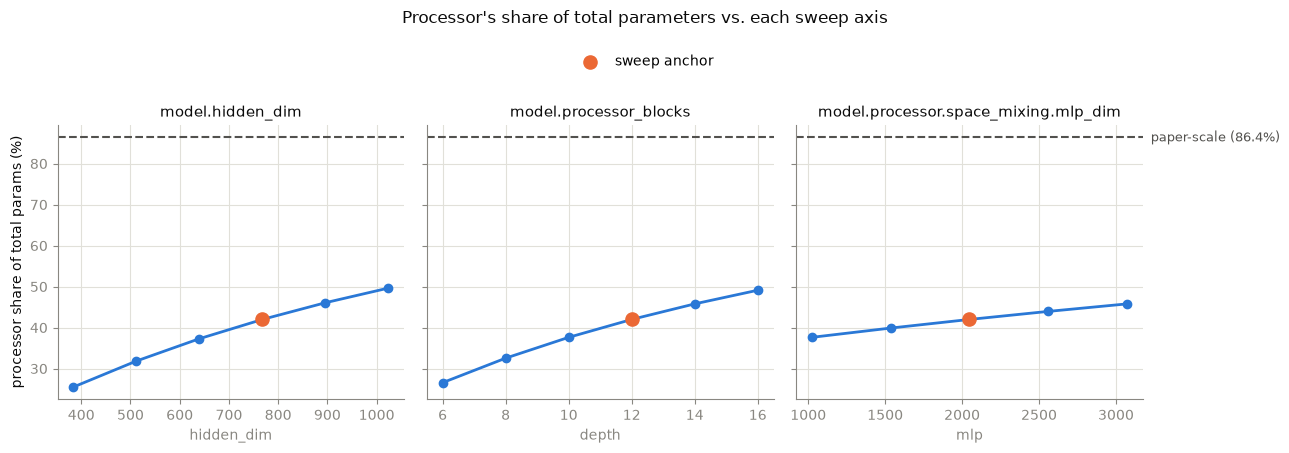

In [11]:
PAPER_PROCESSOR_BLOCKS = 40  # from PAPER_SCALE_OVERRIDES


def depth_used(row):
    return row["value"] if row["axis"] == "depth" else ANCHOR["depth"]


derived_df = sweep_df.copy()
derived_df["processor_share"] = derived_df["processor"] / derived_df["total"]
derived_df["params_per_block"] = derived_df.apply(
    lambda row: millions(row["processor"]) / depth_used(row), axis=1
)

paper_processor_share = paper_stats["processor"] / paper_stats["total"]
paper_params_per_block = millions(paper_stats["processor"]) / PAPER_PROCESSOR_BLOCKS

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharey=True)

for ax, (axis, values) in zip(axes, OPTIONS.items()):
    sub = derived_df[derived_df["axis"] == axis].sort_values("value")
    ax.plot(
        sub["value"], sub["processor_share"] * 100,
        color=SERIES_COLOR, linewidth=2, marker="o", markersize=6, zorder=3,
    )
    anchor_value = ANCHOR[axis]
    anchor_row = sub[sub["value"] == anchor_value].iloc[0]
    ax.scatter(
        [anchor_value], [anchor_row["processor_share"] * 100],
        color=ANCHOR_MARKER_COLOR, s=90, zorder=4, label="sweep anchor",
    )
    ax.axhline(paper_processor_share * 100, color=REFERENCE_COLOR, linewidth=1.5, linestyle="--", zorder=2)
    ax.set_title(AXIS_LABELS[axis], color=INK, fontsize=11)
    ax.set_xlabel(axis, color=MUTED)
    ax.grid(True, color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_ylabel("processor share of total params (%)", color=INK)
axes[-1].text(
    axes[-1].get_xlim()[1], paper_processor_share * 100,
    f"  paper-scale ({paper_processor_share:.1%})",
    color=REFERENCE_COLOR, va="center", fontsize=9,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Processor's share of total parameters vs. each sweep axis", color=INK, fontsize=12, y=1.12)
fig.tight_layout()
plt.show()

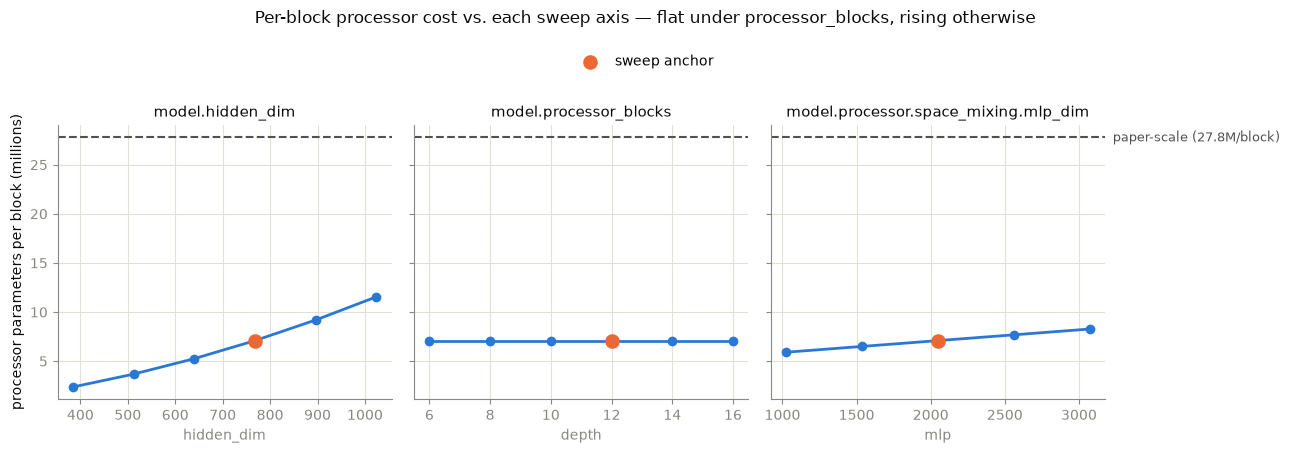

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharey=True)

for ax, (axis, values) in zip(axes, OPTIONS.items()):
    sub = derived_df[derived_df["axis"] == axis].sort_values("value")
    ax.plot(
        sub["value"], sub["params_per_block"],
        color=SERIES_COLOR, linewidth=2, marker="o", markersize=6, zorder=3,
    )
    anchor_value = ANCHOR[axis]
    anchor_row = sub[sub["value"] == anchor_value].iloc[0]
    ax.scatter(
        [anchor_value], [anchor_row["params_per_block"]],
        color=ANCHOR_MARKER_COLOR, s=90, zorder=4, label="sweep anchor",
    )
    ax.axhline(paper_params_per_block, color=REFERENCE_COLOR, linewidth=1.5, linestyle="--", zorder=2)
    ax.set_title(AXIS_LABELS[axis], color=INK, fontsize=11)
    ax.set_xlabel(axis, color=MUTED)
    ax.grid(True, color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_ylabel("processor parameters per block (millions)", color=INK)
axes[-1].text(
    axes[-1].get_xlim()[1], paper_params_per_block,
    f"  paper-scale ({paper_params_per_block:.1f}M/block)",
    color=REFERENCE_COLOR, va="center", fontsize=9,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle(
    "Per-block processor cost vs. each sweep axis — flat under processor_blocks, rising otherwise",
    color=INK, fontsize=12, y=1.12,
)
fig.tight_layout()
plt.show()

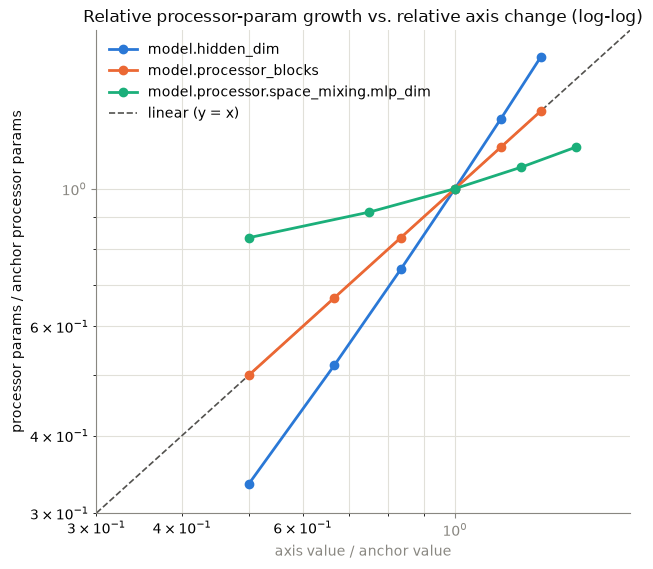

In [13]:
AXIS_COLORS = {"hidden_dim": "#2a78d6", "depth": "#eb6834", "mlp": "#1baf7a"}

# Plotted on *processor* params, not total: the encoder/decoder's fixed ~117M-param floor
# (constant across all three axes here) flattens the total-params curve at the low end
# regardless of the true per-axis scaling law, which would misrepresent the exponents.
# Processor params isolate the actual relationship each axis has with the quantity it scales.
fig, ax = plt.subplots(figsize=(6.5, 5.8))

for axis, values in OPTIONS.items():
    sub = sweep_df[sweep_df["axis"] == axis].sort_values("value")
    anchor_value = ANCHOR[axis]
    anchor_processor = sub[sub["value"] == anchor_value]["processor"].iloc[0]
    rel_x = sub["value"] / anchor_value
    rel_y = sub["processor"] / anchor_processor
    ax.plot(
        rel_x, rel_y, color=AXIS_COLORS[axis], linewidth=2, marker="o", markersize=6,
        label=AXIS_LABELS[axis], zorder=3,
    )

lims = [0.3, 1.8]
ax.plot(lims, lims, color=REFERENCE_COLOR, linewidth=1.2, linestyle="--", zorder=2, label="linear (y = x)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("axis value / anchor value", color=MUTED)
ax.set_ylabel("processor params / anchor processor params", color=INK)
ax.grid(True, which="both", color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Relative processor-param growth vs. relative axis change (log-log)", color=INK, fontsize=12)
fig.tight_layout()
plt.show()

## 8. The same sweep, centered on the original Walrus

Sections 4–7 sweep `hidden_dim`/`processor_blocks`/`mlp_dim` around the small single-node
anchor (768/12/2048), because that's what's cheap enough to search over on one node. But the
scaling *behavior* found there — quadratic-ish `hidden_dim`, linear `processor_blocks`, shallow
`mlp_dim` — is a claim about the architecture's math, not about that specific point, so it
should hold just as well centered on the real Walrus (1408/40/5632). This repeats the section
4/5 plots there directly, 5 points per axis, reusing the already-built `paper_model` for each
axis's center point instead of rebuilding it.

In [14]:
PAPER_ANCHOR = {"hidden_dim": 1408, "depth": 40, "mlp": 5632}
PAPER_OPTIONS = {
    "hidden_dim": [1152, 1280, 1408, 1536, 1664],
    "depth": [32, 36, 40, 44, 48],
    "mlp": [4608, 5120, 5632, 6144, 6656],
}


def paper_axis_overrides(hidden_dim, depth, mlp):
    return [
        "model/processor/space_mixing=full_spatial_attention",
        "model.projection_dim=48",
        "model.intermediate_dim=352",
        f"model.hidden_dim={hidden_dim}",
        "model.groups=16",
        f"model.processor_blocks={depth}",
        "model.drop_path=0.05",
        f"model.processor.space_mixing.mlp_dim={mlp}",
        "model.processor.space_mixing.num_heads=16",
        "model.processor.time_mixing.num_heads=16",
        "model.causal_in_time=True",
        "model.override_dimensionality=0",
    ]


paper_rows = []
for axis, values in PAPER_OPTIONS.items():
    combo = dict(PAPER_ANCHOR)
    for value in values:
        combo[axis] = value
        if value == PAPER_ANCHOR[axis]:
            stats = paper_stats  # exactly PAPER_SCALE_OVERRIDES - reuse, don't rebuild
        else:
            model = build_model(paper_axis_overrides(**combo))
            stats = component_breakdown(model)
        paper_rows.append({"axis": axis, "value": value, **stats})
    combo = dict(PAPER_ANCHOR)

paper_sweep_df = pd.DataFrame(paper_rows)
paper_sweep_df

,axis,value,encoder,processor,decoder,total
0,hidden_dim,1152,76057536,814686720,76055366,966799622
1,hidden_dim,1280,81824960,957608960,81822534,1121256454
2,hidden_dim,1408,87592384,1111016960,87589702,1286199046
3,hidden_dim,1536,93359808,1274910720,93356870,1461627398
4,hidden_dim,1664,99127232,1449290240,99124038,1647541510
5,depth,32,87592384,888813568,87589702,1063995654
6,depth,36,87592384,999915264,87589702,1175097350
7,depth,40,87592384,1111016960,87589702,1286199046
8,depth,44,87592384,1222118656,87589702,1397300742
9,depth,48,87592384,1333220352,87589702,1508402438


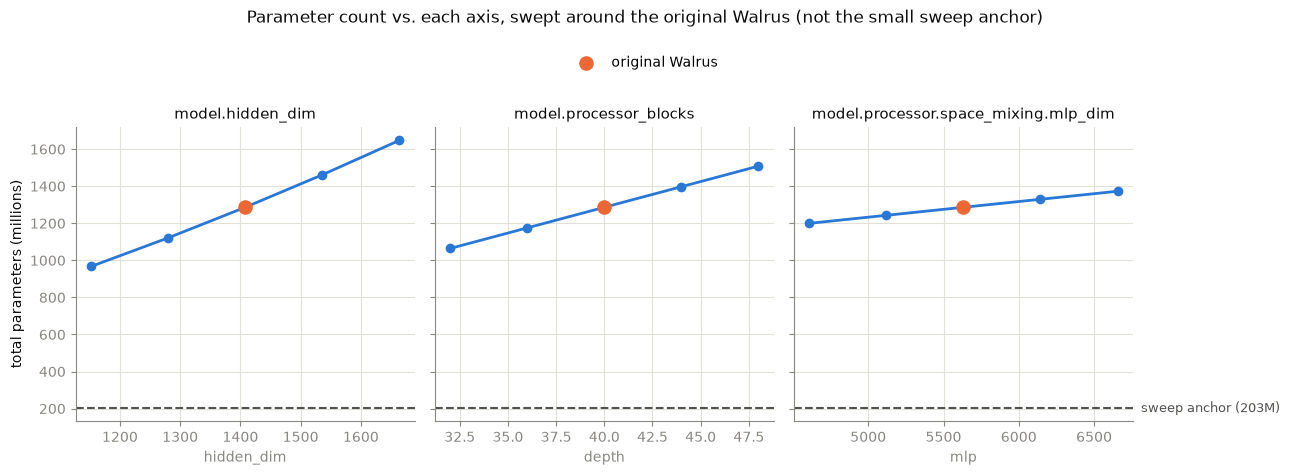

In [15]:
anchor_total_m = millions(anchor_stats["total"])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

for ax, (axis, values) in zip(axes, PAPER_OPTIONS.items()):
    sub = paper_sweep_df[paper_sweep_df["axis"] == axis].sort_values("value")
    ax.plot(
        sub["value"], sub["total"].apply(millions),
        color=SERIES_COLOR, linewidth=2, marker="o", markersize=6, zorder=3,
    )
    center_value = PAPER_ANCHOR[axis]
    center_row = sub[sub["value"] == center_value].iloc[0]
    ax.scatter(
        [center_value], [millions(center_row["total"])],
        color=ANCHOR_MARKER_COLOR, s=90, zorder=4, label="original Walrus",
    )
    ax.axhline(anchor_total_m, color=REFERENCE_COLOR, linewidth=1.5, linestyle="--", zorder=2)
    ax.set_title(AXIS_LABELS[axis], color=INK, fontsize=11)
    ax.set_xlabel(axis, color=MUTED)
    ax.grid(True, color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_ylabel("total parameters (millions)", color=INK)
axes[-1].text(
    axes[-1].get_xlim()[1], anchor_total_m, f"  sweep anchor ({anchor_total_m:,.0f}M)",
    color=REFERENCE_COLOR, va="center", fontsize=9,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle(
    "Parameter count vs. each axis, swept around the original Walrus (not the small sweep anchor)",
    color=INK, fontsize=12, y=1.12,
)
fig.tight_layout()
plt.show()

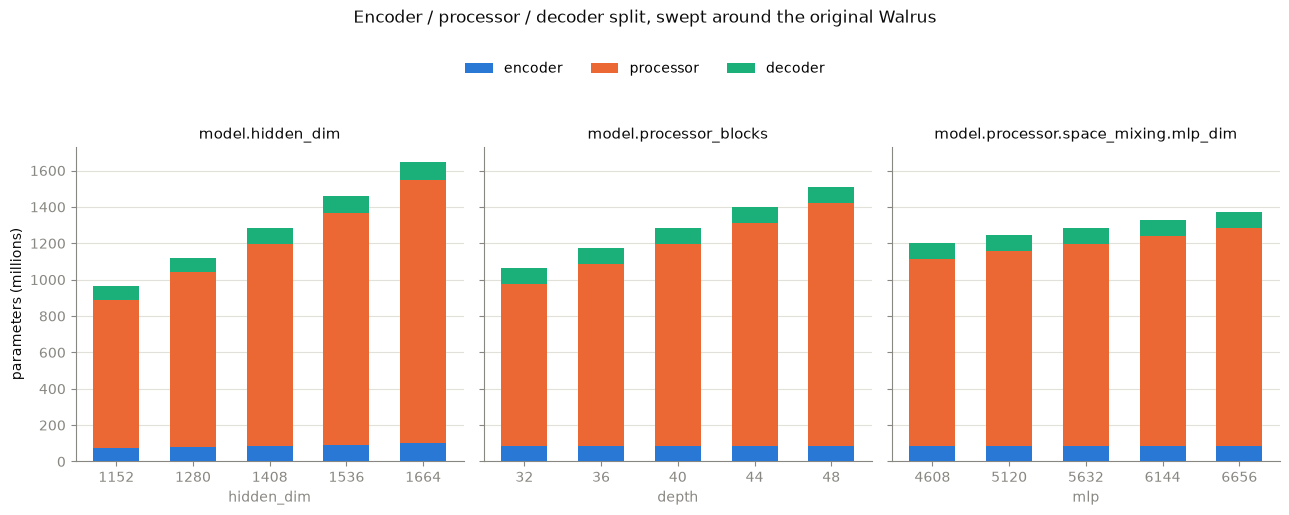

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)

for ax, (axis, values) in zip(axes, PAPER_OPTIONS.items()):
    sub = paper_sweep_df[paper_sweep_df["axis"] == axis].sort_values("value")
    x = range(len(sub))
    bottom = [0.0] * len(sub)
    for component in ["encoder", "processor", "decoder"]:
        heights = sub[component].apply(millions).to_numpy()
        ax.bar(
            x, heights, bottom=bottom, width=0.6,
            color=COMPONENT_COLORS[component], label=component, zorder=3,
        )
        bottom = [b + h for b, h in zip(bottom, heights)]
    ax.set_xticks(list(x))
    ax.set_xticklabels(sub["value"], color=MUTED)
    ax.set_title(AXIS_LABELS[axis], color=INK, fontsize=11)
    ax.set_xlabel(axis, color=MUTED)
    ax.grid(True, axis="y", color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_ylabel("parameters (millions)", color=INK)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.07))
fig.suptitle(
    "Encoder / processor / decoder split, swept around the original Walrus",
    color=INK, fontsize=12, y=1.16,
)
fig.tight_layout()
plt.show()

## 9. Inside the architecture

Every plot so far has been about *how many* parameters a config produces. This section is about
*where* they physically sit — first as a diagram of what paper-scale Walrus actually is
structurally, then as bar charts of parameter count one level below "encoder/processor/decoder,"
down to the individual weight matrices. Everything here is read directly off `paper_model`
(already built in section 2 — no new model builds).

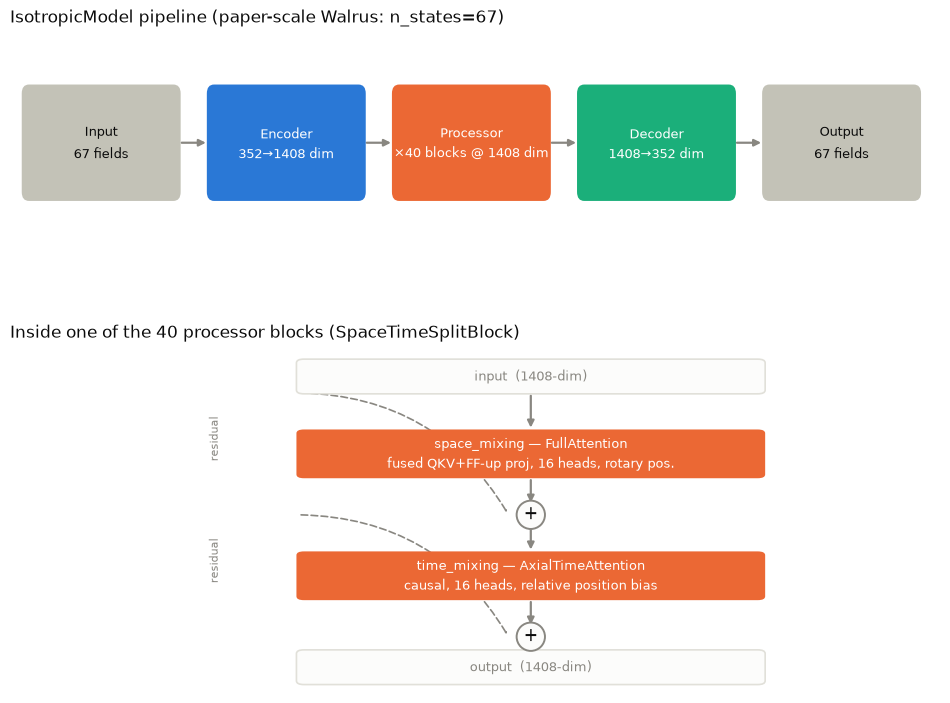

In [17]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

NEUTRAL = "#c3c2b7"
SURFACE = "#fcfcfb"

fig = plt.figure(figsize=(12, 8.6))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.55], hspace=0.32)


def rounded_box(ax, x, y, w, h, color, text, textcolor, fontsize=9.5, edge=None):
    box = FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=1.2 if edge else 0, edgecolor=edge or "none",
        facecolor=color, zorder=3,
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", color=textcolor,
             fontsize=fontsize, zorder=4, linespacing=1.5)


def straight_arrow(ax, xy0, xy1, **kwargs):
    defaults = dict(arrowstyle="-|>", color=MUTED, linewidth=1.6, shrinkA=2, shrinkB=2)
    defaults.update(kwargs)
    ax.annotate("", xy=xy1, xytext=xy0, arrowprops=defaults, zorder=2)


def plus_node(ax, x, y):
    # bbox is sized in points (display space), so it renders as a true circle
    # regardless of the axes' data aspect ratio - unlike a patches.Circle in data coords.
    ax.text(
        x, y, "+", ha="center", va="center", color=INK, fontsize=12, zorder=6,
        bbox=dict(boxstyle="circle,pad=0.35", facecolor=SURFACE, edgecolor=MUTED, linewidth=1.4),
    )


# --- Panel 1: end-to-end pipeline ---
ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(0, 10.3)
ax1.set_ylim(0, 2)
ax1.axis("off")
ax1.set_title("IsotropicModel pipeline (paper-scale Walrus: n_states=67)", color=INK, fontsize=12, loc="left")

stages = [
    ("Input\n67 fields", NEUTRAL, INK),
    ("Encoder\n352→1408 dim", COMPONENT_COLORS["encoder"], "white"),
    ("Processor\n×40 blocks @ 1408 dim", COMPONENT_COLORS["processor"], "white"),
    ("Decoder\n1408→352 dim", COMPONENT_COLORS["decoder"], "white"),
    ("Output\n67 fields", NEUTRAL, INK),
]
box_w, box_h, gap = 1.72, 1.0, 0.33
x = 0.15
centers = []
for label, color, textcolor in stages:
    rounded_box(ax1, x, 0.5, box_w, box_h, color, label, textcolor)
    centers.append((x, x + box_w))
    x += box_w + gap

for (_, x0), (x1, _) in zip(centers, centers[1:]):
    straight_arrow(ax1, (x0, 1.0), (x1, 1.0))

# --- Panel 2: one processor block's internals ---
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10)
ax2.set_ylim(1.5, 8.9)
ax2.axis("off")
ax2.set_title(
    "Inside one of the 40 processor blocks (SpaceTimeSplitBlock)", color=INK, fontsize=12, loc="left",
)

cx = 5.6
node_w, node_h = 5.0, 1.0

rounded_box(ax2, cx - node_w / 2, 7.9, node_w, 0.7, SURFACE, "input  (1408-dim)", MUTED, edge=GRIDLINE_COLOR)
rounded_box(
    ax2, cx - node_w / 2, 6.1, node_w, node_h, COMPONENT_COLORS["processor"],
    "space_mixing — FullAttention\nfused QKV+FF-up proj, 16 heads, rotary pos.", "white",
)
plus1_y = 5.3
plus_node(ax2, cx, plus1_y)
rounded_box(
    ax2, cx - node_w / 2, 3.5, node_w, node_h, COMPONENT_COLORS["processor"],
    "time_mixing — AxialTimeAttention\ncausal, 16 heads, relative position bias", "white",
)
plus2_y = 2.7
plus_node(ax2, cx, plus2_y)
rounded_box(ax2, cx - node_w / 2, 1.7, node_w, 0.7, SURFACE, "output  (1408-dim)", MUTED, edge=GRIDLINE_COLOR)

straight_arrow(ax2, (cx, 7.9), (cx, 7.1))
straight_arrow(ax2, (cx, 6.1), (cx, plus1_y + 0.2))
straight_arrow(ax2, (cx, plus1_y - 0.2), (cx, 4.5))
straight_arrow(ax2, (cx, 3.5), (cx, plus2_y + 0.2))
straight_arrow(ax2, (cx, plus2_y - 0.2), (cx, 2.4))

skip_x = cx - node_w / 2 - 0.9
for y0, y1 in [(7.9, plus1_y), (plus1_y, plus2_y)]:
    skip = FancyArrowPatch(
        (cx - node_w / 2, y0), (cx - 0.24, y1),
        connectionstyle="arc3,rad=-0.28",
        arrowstyle="-|>", color=MUTED, linewidth=1.2, linestyle=(0, (4, 2)), zorder=2,
    )
    ax2.add_patch(skip)
ax2.text(skip_x, (7.9 + plus1_y) / 2 - 0.1, "residual", color=MUTED, fontsize=8, ha="center", rotation=90)
ax2.text(skip_x, (plus1_y + plus2_y) / 2 - 0.1, "residual", color=MUTED, fontsize=8, ha="center", rotation=90)

plt.show()

One detail the diagram's label already hints at: `space_mixing`'s attention QKV projection and
its feed-forward "up" projection aren't separate matrices — they're one fused linear layer
(`fused_ff_qkv`, printed below). That's *why* `hidden_dim` scales worse than linearly and
`mlp_dim` scales shallowly (section 8's takeaway): that single matrix has shape
`hidden_dim × (3·hidden_dim + mlp_dim)`, so `hidden_dim` appears twice (quadratic) while
`mlp_dim` only adds to it once (linear). Printing the real block confirms the diagram wasn't
simplifying anything essential:

In [18]:
print(paper_model.blocks[0])

SpaceTimeSplitBlock(
  (space_mixing): FullAttention(
    (norm1): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    (fused_ff_qkv): Linear(in_features=1408, out_features=9856, bias=True)
    (activation): SwiGLU()
    (ff_out): Linear(in_features=2816, out_features=1408, bias=True)
    (attn_out): Linear(in_features=1408, out_features=1408, bias=False)
    (q_norm): LayerNorm((88,), eps=1e-05, elementwise_affine=True)
    (k_norm): LayerNorm((88,), eps=1e-05, elementwise_affine=True)
    (rotary_emb): RotaryEmbedding()
    (drop_path): Identity()
  )
  (time_mixing): AxialTimeAttention(
    (norm1): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    (input_head): Conv3d(1408, 4224, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (output_head): Conv3d(1408, 1408, kernel_size=(1, 1, 1), stride=(1, 1, 1))
    (qnorm): LayerNorm((88,), eps=1e-05, elementwise_affine=True)
    (knorm): LayerNorm((88,), eps=1e-05, elementwise_affine=True)
    (rel_pos_bias): RelativePositionBias(
      (relati

In [19]:
block0 = paper_model.blocks[0]

block_parts = {
    "space_mixing": count_params(block0.space_mixing),
    "time_mixing": count_params(block0.time_mixing),
    "channel_mixing": count_params(block0.channel_mixing),  # nn.Identity - unused in this config
}

space_mixing_parts = {
    "fused_ff_qkv\n(attn QKV + FF-up, fused)": count_params(block0.space_mixing.fused_ff_qkv),
    "attn_out": count_params(block0.space_mixing.attn_out),
    "ff_out": count_params(block0.space_mixing.ff_out),
    "norms\n(norm1/q_norm/k_norm)": (
        count_params(block0.space_mixing.norm1)
        + count_params(block0.space_mixing.q_norm)
        + count_params(block0.space_mixing.k_norm)
    ),
}

time_mixing_parts = {
    "input_head": count_params(block0.time_mixing.input_head),
    "output_head": count_params(block0.time_mixing.output_head),
    "rel_pos_bias": count_params(block0.time_mixing.rel_pos_bias),
    "norms\n(norm1/qnorm/knorm)": (
        count_params(block0.time_mixing.norm1)
        + count_params(block0.time_mixing.qnorm)
        + count_params(block0.time_mixing.knorm)
    ),
}


def encoder_layer_breakdown(enc):
    return {
        "proj1 (patchify conv)": count_params(enc.proj1),
        "norm1": count_params(enc.norm1),
        "proj2 (to hidden_dim)": count_params(enc.proj2),
        "norm2": count_params(enc.norm2),
    }


def decoder_layer_breakdown(dec):
    return {
        "proj1 (from hidden_dim)": count_params(dec.proj1),
        "norm1": count_params(dec.norm1),
        "proj2 (unpatchify conv)": count_params(dec.proj2),
    }


def aggregate_layer_breakdown(module_dict, layer_breakdown_fn):
    totals = {}
    for m in module_dict.values():  # sum over the "2"/"3" spatial-dim variants
        for k, v in layer_breakdown_fn(m).items():
            totals[k] = totals.get(k, 0) + v
    return totals


encoder_parts = aggregate_layer_breakdown(paper_model.embed, encoder_layer_breakdown)
decoder_parts = aggregate_layer_breakdown(paper_model.debed, decoder_layer_breakdown)

print("one processor block:", {k: f"{millions(v):.2f}M" for k, v in block_parts.items()})
print("encoder (both spatial dims):", {k: f"{millions(v):.2f}M" for k, v in encoder_parts.items()})
print("decoder (both spatial dims):", {k: f"{millions(v):.2f}M" for k, v in decoder_parts.items()})

one processor block: {'space_mixing': '19.84M', 'time_mixing': '7.94M', 'channel_mixing': '0.00M'}
encoder (both spatial dims): {'proj1 (patchify conv)': '24.15M', 'norm1': '0.00M', 'proj2 (to hidden_dim)': '63.44M', 'norm2': '0.00M'}
decoder (both spatial dims): {'proj1 (from hidden_dim)': '63.44M', 'norm1': '0.00M', 'proj2 (unpatchify conv)': '24.15M'}


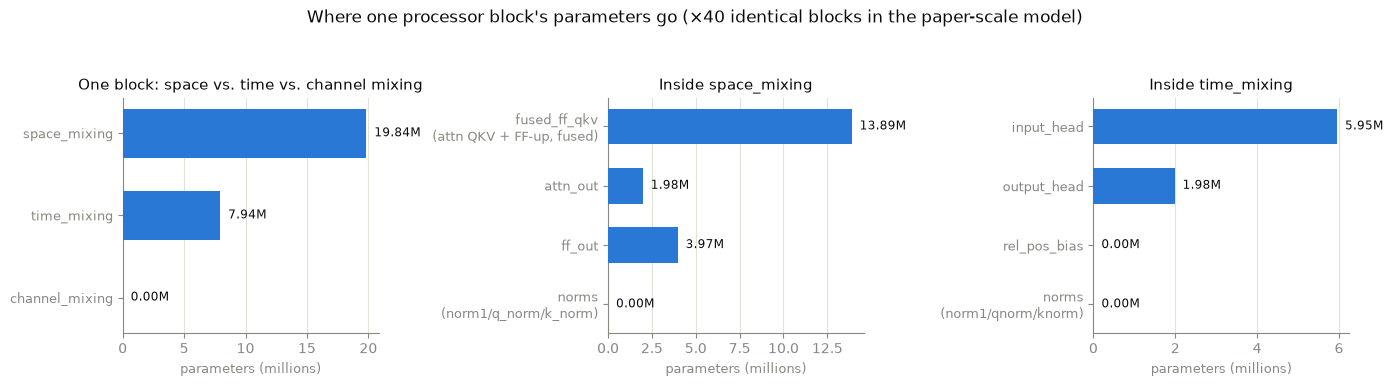

In [20]:
def hbar_panel(ax, parts, title, unit_scale=1e6, color=SERIES_COLOR):
    labels = list(parts.keys())
    values = [v / unit_scale for v in parts.values()]
    y = range(len(labels))
    ax.barh(y, values, color=color, height=0.6, zorder=3)
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, color=MUTED, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, color=INK, fontsize=11)
    ax.grid(True, axis="x", color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)
    for yi, v in zip(y, values):
        ax.text(v, yi, f"  {v:.2f}M", va="center", color=INK, fontsize=8.5, zorder=4)


fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
hbar_panel(axes[0], block_parts, "One block: space vs. time vs. channel mixing")
hbar_panel(axes[1], space_mixing_parts, "Inside space_mixing")
hbar_panel(axes[2], time_mixing_parts, "Inside time_mixing")
for ax in axes:
    ax.set_xlabel("parameters (millions)", color=MUTED, fontsize=9)
fig.suptitle(
    "Where one processor block's parameters go (×40 identical blocks in the paper-scale model)",
    color=INK, fontsize=12, y=1.06,
)
fig.tight_layout()
plt.show()

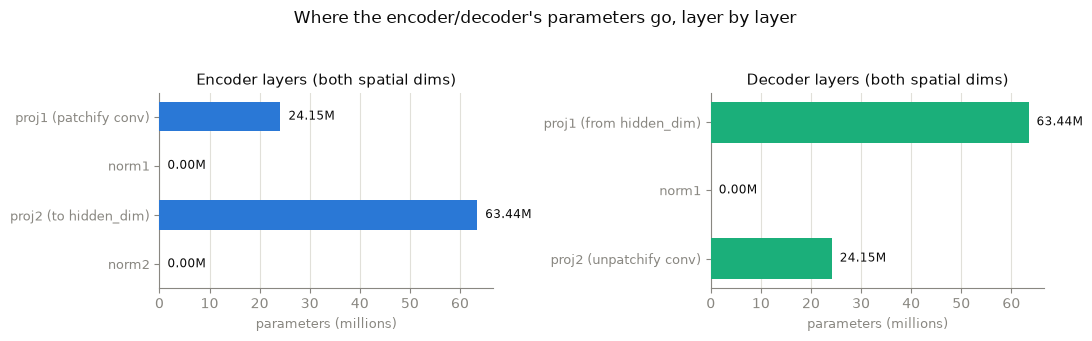

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
hbar_panel(axes[0], encoder_parts, "Encoder layers (both spatial dims)", color=COMPONENT_COLORS["encoder"])
hbar_panel(axes[1], decoder_parts, "Decoder layers (both spatial dims)", color=COMPONENT_COLORS["decoder"])
for ax in axes:
    ax.set_xlabel("parameters (millions)", color=MUTED, fontsize=9)
fig.suptitle("Where the encoder/decoder's parameters go, layer by layer", color=INK, fontsize=12, y=1.05)
fig.tight_layout()
plt.show()

## 10. Takeaways

- **The processor dominates.** At paper scale it's ~86% of all parameters; at the sweep anchor,
  ~42% (the encoder/decoder don't shrink with the processor, so they become relatively larger in
  the smaller model). Section 7's processor-share plot shows this fraction rising with every
  processor-scaling axis, approaching the paper-scale reference line as each axis grows. Any axis
  that scales the processor will dominate total size.
- **`processor_blocks` (depth) scales linearly** — each block is identical, so doubling depth
  roughly doubles the processor's parameter count. This is the cheapest, most predictable axis.
  Section 7's per-block plot confirms it directly: params-per-block is flat under this axis, and
  the log-log relative-growth plot puts it right on the *y = x* reference line.
- **`hidden_dim` scales worse than linearly** — and section 9 shows exactly why: `space_mixing`'s
  attention QKV and feed-forward "up" projections are fused into one `fused_ff_qkv` matrix of
  shape `hidden_dim × (3·hidden_dim + mlp_dim)`, so `hidden_dim` appears both as the matrix's
  input width *and* inside its output width — genuinely quadratic, not just "close to." Its
  log-log curve sits visibly above the *y = x* line in section 7, and its per-block cost keeps
  climbing rather than staying flat.
- **`mlp_dim` only adds to that same fused matrix's output width once**, linearly, which is why
  its slope is the shallowest of the three despite being the axis with the widest range of
  options in the sweep — its log-log curve sits below both `hidden_dim` and the linear reference.
- **`groups` and `projection_dim` don't move parameter count at all — not "less," but exactly
  zero.** Section 6 sweeps both across a wide range and gets the *identical* total every time
  (202,571,270 params, down to the last digit), and section 6's follow-up traces why in the
  source: `RMSGroupNorm`'s affine parameters are shaped by channel count, not group count, and
  `projection_dim` never reaches a learnable weight at all. The attention head counts
  (`num_heads`) move it by ~0.005% — functionally also flat. Of the encoder/decoder-side knobs,
  only `intermediate_dim` is a genuine size lever.
- **The scaling laws hold at real scale, not just around the cheap anchor.** Section 8 reruns
  the section 4/5 sweeps centered on the actual paper values (1408/40/5632) instead of the small
  single-node anchor (768/12/2048), and the same shapes show up: `hidden_dim` curves upward
  fastest, `processor_blocks` is the straight line, `mlp_dim` is the shallowest. The anchor is a
  6.3x-cheaper stand-in for exploring these axes, not a different architecture.
- **`time_mixing` is consistently cheaper than `space_mixing`** (section 9's block breakdown) —
  `AxialTimeAttention`'s `input_head`/`output_head` are 1×1×1 convolutions at `hidden_dim`, with
  no fused feed-forward riding along, while `space_mixing`'s `fused_ff_qkv` carries both the
  attention projection *and* the block's entire feed-forward capacity. Encoder and decoder mirror
  each other almost exactly, layer for layer, as the "mirror image" framing in section 1 claimed.

## 11. A closed-form parameter-count formula

Every number so far came from actually instantiating an `IsotropicModel` and calling
`count_params`. That's exact, but it needs Hydra + the full `walrus` package and takes a moment
per config. Sections 1-9 already pinned down every term that matters:

- **processor** - each block is `space_mixing` (`FullAttention`) + `time_mixing`
  (`AxialTimeAttention`) + `channel_mixing` (`nn.Identity` by default, 0 params), repeated
  `processor_blocks` times. Section 9 named every weight matrix inside the first two.
- **encoder/decoder** - `SpaceBagAdaptiveDVstrideEncoder` / `AdaptiveDVstrideDecoder`, one copy
  per entry in `include_d` (2 by default: dim-keys `"2"` and `"3"`) - and `IsotropicModel`
  hardcodes `spatial_dims=3` for *every* copy regardless of key, so both copies are identically
  sized. Each is two conv layers: an `8x8x8`-kernel patchify conv (`n_states -> intermediate_dim`)
  and a `4x4x4`-kernel conv up to `hidden_dim` (kernel sizes from the repo's default
  `base_kernel_size3d`).
- **`groups` and `projection_dim` don't appear at all** - section 6 showed they have exactly zero
  effect on parameter count, so a correct closed-form formula simply has no term for them.

`analytic_param_count` below reimplements this directly from `nn.Linear`/`nn.Conv3d`/
`nn.LayerNorm`/`RMSGroupNorm` shapes - no Hydra, no `nn.Module`, just arithmetic - so it's cheap
enough to call on every slider tick in section 12.

In [22]:
def analytic_param_count(
    hidden_dim=768,
    processor_blocks=12,
    mlp_dim=None,           # None -> hidden_dim * 4, FullAttention's own default
    intermediate_dim=192,
    n_states=67,
    num_heads=12,
    n_dim_keys=2,            # len(include_d) - default include_d=[2, 3] builds 2 identical copies
    bias_type_time="rel",    # axial_time_attention default; 'rotary'/'none' add ~0 params instead
    num_buckets=32,          # RelativePositionBias's fixed bucket count (only matters if bias_type_time="rel")
):
    """Closed-form parameter count for IsotropicModel, for the architecture family this notebook
    explores throughout: model/processor/space_mixing=full_spatial_attention, default
    time_mixing=axial_time_attention, default channel_mixing=identity, default
    norm_layer=rmsgroupnorm, default encoder/decoder=spacebag_and_vstride_encoder/vstride_decoder.
    Matches walrus/models/spatial_blocks/full_attention.py, temporal_blocks/axial_time_attention.py,
    encoders/vstride_encoder.py and decoders/vstride_decoder.py term-for-term - no Hydra, no
    nn.Module construction. Cross-checked bit-for-bit against count_params() below.

    Not arguments: `groups`, `projection_dim` - section 6 confirmed they don't affect param count.
    """
    H = hidden_dim
    M = mlp_dim if mlp_dim is not None else H * 4
    nh = num_heads
    I = intermediate_dim

    # --- space_mixing: FullAttention (per block) ---
    space = H                                # norm1: RMSGroupNorm affine weight only
    space += H * (M + 3 * H) + (M + 3 * H)   # fused_ff_qkv: Linear(H, M + 3H), weight + bias
    space += (M // 2) * H + H                # ff_out: Linear(M // 2, H), weight + bias
    space += H * H                           # attn_out: Linear(H, H, bias=False)
    space += 4 * (H // nh)                   # q_norm + k_norm: LayerNorm(H / nh) each, weight + bias

    # --- time_mixing: AxialTimeAttention (per block) ---
    time = H                                 # norm1
    time += 3 * H * H + 3 * H                # input_head: Conv3d(H, 3H, kernel=1), weight + bias
    time += H * H + H                        # output_head: Conv3d(H, H, kernel=1), weight + bias
    time += 4 * (H // nh)                    # qnorm + knorm
    if bias_type_time == "rel":
        time += num_buckets * nh             # RelativePositionBias: Embedding(num_buckets, num_heads)

    # channel_mixing defaults to nn.Identity -> 0 params, not included

    processor = (space + time) * processor_blocks

    # --- encoder / decoder: one identically-sized copy per include_d entry ---
    # IsotropicModel hardcodes spatial_dims=3 for every copy, so kernel sizes come from
    # base_kernel_size3d = [[8, 4], [8, 4], [8, 4]]: 8x8x8 for the patchify conv, 4x4x4 for the
    # dim-raising conv (mirrored in the decoder).
    enc_per_key = I * n_states * 512 + I + H * I * 64 + H   # proj1 + norm1 + proj2 + norm2
    encoder = enc_per_key * n_dim_keys

    dec_per_key = H * I * 64 + I + I * n_states * 512 + n_states  # proj1 + norm1 + proj2(w+b)
    decoder = dec_per_key * n_dim_keys

    total = encoder + processor + decoder
    return {"encoder": encoder, "processor": processor, "decoder": decoder, "total": total}


In [23]:
# Validate against every model already built in this notebook - no new nn.Module construction.
paper_pred = analytic_param_count(
    hidden_dim=1408, processor_blocks=40, mlp_dim=1408 * 4, intermediate_dim=352, n_states=67, num_heads=16,
)
anchor_pred = analytic_param_count(
    hidden_dim=ANCHOR["hidden_dim"], processor_blocks=ANCHOR["depth"], mlp_dim=ANCHOR["mlp"],
    intermediate_dim=352, n_states=67, num_heads=HEADS,
)
print("paper_stats  exact match:", paper_pred == paper_stats)
print("anchor_stats exact match:", anchor_pred == anchor_stats)

# Section 4's full hidden_dim/depth/mlp sweep (30 configs) and section 6's full
# projection_dim/intermediate_dim/groups/heads sweep (21 configs) - reusing sweep_df and
# component_sweep_df exactly as already computed.
sweep_diffs = []
for _, row in sweep_df.iterrows():
    combo = dict(ANCHOR)
    combo[row["axis"]] = row["value"]
    pred = analytic_param_count(
        hidden_dim=combo["hidden_dim"], processor_blocks=combo["depth"], mlp_dim=combo["mlp"],
        intermediate_dim=352, n_states=67, num_heads=HEADS,
    )
    sweep_diffs.append(pred["total"] - row["total"])

component_diffs = []
for _, row in component_sweep_df.iterrows():
    combo = dict(COMPONENT_ANCHOR)
    combo[row["axis"]] = row["value"]
    pred = analytic_param_count(
        hidden_dim=ANCHOR["hidden_dim"], processor_blocks=ANCHOR["depth"], mlp_dim=ANCHOR["mlp"],
        intermediate_dim=combo["intermediate_dim"], n_states=67, num_heads=combo["heads"],
    )
    component_diffs.append(pred["total"] - row["total"])

print(f"section 4 sweep ({len(sweep_diffs)} configs): max |diff| = {max(abs(d) for d in sweep_diffs)}")
print(f"section 6 sweep ({len(component_diffs)} configs): max |diff| = {max(abs(d) for d in component_diffs)}")


paper_stats  exact match: True
anchor_stats exact match: True
section 4 sweep (17 configs): max |diff| = 0
section 6 sweep (21 configs): max |diff| = 0


## 12. Interactive explorer

Because `analytic_param_count` is pure arithmetic, it's cheap enough to recompute on every slider
move. Drag `hidden_dim`, `processor_blocks` (depth), `mlp_dim`, `intermediate_dim`, `n_states`,
`num_heads`, and the number of `include_d` copies to see the encoder/processor/decoder split and
total parameter count update live, against the original Walrus (dashed line) for scale. This is
the same formula validated in section 11 - not a separate approximation.

In [24]:
import ipywidgets as widgets
from IPython.display import display


def plot_interactive(hidden_dim, processor_blocks, mlp_dim, intermediate_dim, n_states, num_heads, n_dim_keys, bias_type_time):
    stats = analytic_param_count(
        hidden_dim=hidden_dim, processor_blocks=processor_blocks, mlp_dim=mlp_dim,
        intermediate_dim=intermediate_dim, n_states=n_states, num_heads=num_heads,
        n_dim_keys=n_dim_keys, bias_type_time=bias_type_time,
    )
    total_m = millions(stats["total"])
    paper_total_m = millions(paper_stats["total"])

    fig, ax = plt.subplots(figsize=(8, 2.6))
    left = 0.0
    for component in ["encoder", "processor", "decoder"]:
        val = millions(stats[component])
        ax.barh([0], [val], left=left, color=COMPONENT_COLORS[component], height=0.55, label=component, zorder=3)
        left += val

    xmax = max(paper_total_m, total_m) * 1.15
    ax.set_xlim(0, xmax)
    ax.set_ylim(-1.1, 1.6)
    ax.set_yticks([])
    ax.set_xlabel("parameters (millions)", color=MUTED)
    ax.axvline(paper_total_m, color=REFERENCE_COLOR, linewidth=1.4, linestyle="--", zorder=2)
    ax.text(paper_total_m, -0.85, f"original Walrus ({paper_total_m:,.0f}M)", color=REFERENCE_COLOR,
            fontsize=8.5, ha="center", va="top")
    ax.text(
        0.0, 1.15,
        f"total: {total_m:,.1f}M params   "
        f"(encoder {millions(stats['encoder']):.1f}M \u00b7 processor {millions(stats['processor']):.1f}M \u00b7 "
        f"decoder {millions(stats['decoder']):.1f}M)",
        transform=ax.transAxes, fontsize=11, color=INK,
    )
    if hidden_dim % num_heads != 0:
        ax.text(0.0, -1.05, "note: hidden_dim isn't divisible by num_heads - not a buildable config, formula still applies",
                transform=ax.transAxes, fontsize=8, color=ANCHOR_MARKER_COLOR)
    ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=3, bbox_to_anchor=(1.0, 1.3))
    ax.grid(True, axis="x", color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)
    fig.tight_layout()
    plt.show()


widgets.interact(
    plot_interactive,
    hidden_dim=widgets.IntSlider(min=128, max=2048, step=64, value=ANCHOR["hidden_dim"], description="hidden_dim", continuous_update=False),
    processor_blocks=widgets.IntSlider(min=1, max=48, step=1, value=ANCHOR["depth"], description="depth", continuous_update=False),
    mlp_dim=widgets.IntSlider(min=256, max=6656, step=128, value=ANCHOR["mlp"], description="mlp_dim", continuous_update=False),
    intermediate_dim=widgets.IntSlider(min=64, max=768, step=32, value=352, description="intermediate_dim", continuous_update=False),
    n_states=widgets.IntSlider(min=1, max=100, step=1, value=67, description="n_states", continuous_update=False),
    num_heads=widgets.Dropdown(options=[4, 8, 12, 16, 24, 32], value=16, description="num_heads"),
    n_dim_keys=widgets.Dropdown(options=[1, 2], value=2, description="#include_d"),
    bias_type_time=widgets.Dropdown(options=["rel", "rotary", "none"], value="rel", description="time bias"),
);


interactive(children=(IntSlider(value=768, continuous_update=False, description='hidden_dim', max=2048, min=12…

## 13. Sizing a `quartDims` config (~300M params)

`LeonardoRunScripts/fullDims_*.sh` (1.3B, the paper-scale model from section 2) and
`halfDims_*.sh` (~644M) only ever move two axes against each other: `hidden_dim`
(1408 -> 1088) and `processor_blocks` (40 -> 30). `intermediate_dim=352`, `projection_dim=48`,
`groups=16`, `num_heads=16` are identical in both scripts, and `mlp_dim` is always left at its
`4 x hidden_dim` default (`halfDims` just spells out `4352 = 1088 * 4`). So a `quartDims` point
should stay on that same two-axis line rather than introduce a new architecture shape.

Using `analytic_param_count` (no model builds needed) to search `hidden_dim`/`processor_blocks`
pairs near a ~300M target:

In [25]:
FULL_DIMS = {"hidden_dim": 1408, "depth": 40}
HALF_DIMS = {"hidden_dim": 1088, "depth": 30}

full_dims_stats = analytic_param_count(hidden_dim=FULL_DIMS["hidden_dim"], processor_blocks=FULL_DIMS["depth"],
                                        intermediate_dim=352, n_states=67, num_heads=16)
half_dims_stats = analytic_param_count(hidden_dim=HALF_DIMS["hidden_dim"], processor_blocks=HALF_DIMS["depth"],
                                        intermediate_dim=352, n_states=67, num_heads=16)

target = 300e6
quart_candidates = []
for H in range(512, HALF_DIMS["hidden_dim"] + 1, 32):        # multiples of 32, matching 1408/1088's own spacing
    for D in range(10, HALF_DIMS["depth"] + 1, 2):
        if H % 16 != 0:
            continue
        stats = analytic_param_count(hidden_dim=H, processor_blocks=D, intermediate_dim=352, n_states=67, num_heads=16)
        quart_candidates.append({"hidden_dim": H, "depth": D, **stats, "diff": abs(stats["total"] - target)})

quart_candidates_df = pd.DataFrame(quart_candidates).sort_values("diff").head(10)
quart_candidates_df[["hidden_dim", "depth", "encoder", "processor", "decoder", "total"]].assign(
    **{"total (M)": lambda d: (d["total"] / 1e6).round(1)}
)


,hidden_dim,depth,encoder,processor,decoder,total,total (M)
104,800,20,60197120,179442240,60195654,299835014,299.8
187,1056,10,71731968,156277280,71729990,299739238,299.7
94,768,22,58755264,181922048,58753862,299431174,299.4
145,928,14,65964544,168987616,65962822,300914982,300.9
65,672,30,54429696,189972960,54428486,298831142,298.8
114,832,18,61638976,174666816,61637446,297943238,297.9
84,736,24,57313408,182278272,57312070,296903750,296.9
166,992,12,68848256,165501504,68846406,303196166,303.2
75,704,28,55871552,194581632,55870278,306323462,306.3
124,864,16,63080832,167423744,63079238,293583814,293.6


`hidden_dim=768, processor_blocks=22` comes out closest (299.4M, 0.2% off target) and keeps the
pattern clean: `hidden_dim` steps by a constant -320 across all three points (1408 -> 1088 -> 768),
same as `fullDims` -> `halfDims` already did. Confirmed against an actually-instantiated model
(not just the formula) in the cell after next - exact match, not an approximation.

In [26]:
QUART_DIMS = {"hidden_dim": 768, "depth": 22}
quart_dims_stats = analytic_param_count(hidden_dim=QUART_DIMS["hidden_dim"], processor_blocks=QUART_DIMS["depth"],
                                         intermediate_dim=352, n_states=67, num_heads=16)

comparison_df = pd.DataFrame([
    {"config": "fullDims", **FULL_DIMS, **full_dims_stats},
    {"config": "halfDims", **HALF_DIMS, **half_dims_stats},
    {"config": "quartDims", **QUART_DIMS, **quart_dims_stats},
])
comparison_df["total_M"] = (comparison_df["total"] / 1e6).round(1)
comparison_df["% of fullDims"] = (100 * comparison_df["total"] / full_dims_stats["total"]).round(1)
comparison_df[["config", "hidden_dim", "depth", "total_M", "% of fullDims"]]


,config,hidden_dim,depth,total_M,% of fullDims
0,fullDims,1408,40,1286.2,100.0
1,halfDims,1088,30,644.0,50.1
2,quartDims,768,22,299.4,23.3


In [27]:
# Verify against an actually-instantiated model, not just the closed-form formula.
QUART_DIMS_OVERRIDES = [
    "model/processor/space_mixing=full_spatial_attention",
    "model.projection_dim=48",
    "model.intermediate_dim=352",
    f"model.hidden_dim={QUART_DIMS['hidden_dim']}",
    "model.groups=16",
    f"model.processor_blocks={QUART_DIMS['depth']}",
    "model.drop_path=0.05",
    f"model.processor.space_mixing.mlp_dim={QUART_DIMS['hidden_dim'] * 4}",
    "model.processor.space_mixing.num_heads=16",
    "model.processor.time_mixing.num_heads=16",
    "model.causal_in_time=True",
    "model.jitter_patches=True",
    "model.override_dimensionality=0",
]
quart_model = build_model(QUART_DIMS_OVERRIDES)
quart_model_stats = component_breakdown(quart_model)
print("formula: ", quart_dims_stats)
print("built model:", quart_model_stats)
print("exact match:", quart_model_stats == quart_dims_stats)


formula:  {'encoder': 58755264, 'processor': 181922048, 'decoder': 58753862, 'total': 299431174}
built model: {'encoder': 58755264, 'processor': 181922048, 'decoder': 58753862, 'total': 299431174}
exact match: True


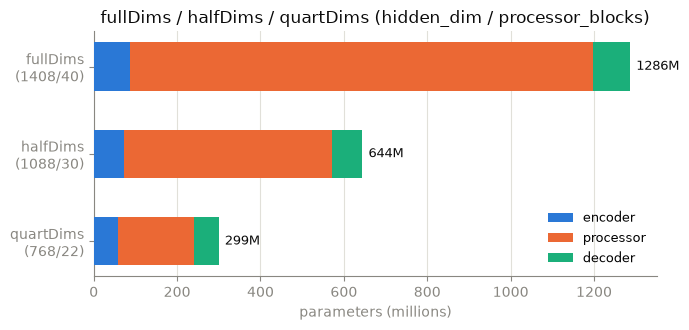

In [28]:
fig, ax = plt.subplots(figsize=(7, 3.4))
configs = ["fullDims", "halfDims", "quartDims"]
y = range(len(configs))
bottom = [0.0] * len(configs)
for component in ["encoder", "processor", "decoder"]:
    heights = [millions(comparison_df.set_index("config").loc[c, component]) for c in configs]
    ax.barh(y, heights, left=bottom, color=COMPONENT_COLORS[component], label=component, height=0.55, zorder=3)
    bottom = [b + h for b, h in zip(bottom, heights)]
ax.set_yticks(list(y))
ax.set_yticklabels([f"{c}\n({comparison_df.set_index('config').loc[c, 'hidden_dim']}/"
                     f"{comparison_df.set_index('config').loc[c, 'depth']})" for c in configs], color=MUTED)
ax.invert_yaxis()
ax.set_xlabel("parameters (millions)", color=MUTED)
for yi, c in zip(y, configs):
    total_m = comparison_df.set_index("config").loc[c, "total_M"]
    ax.text(bottom[yi] if False else comparison_df.set_index("config").loc[c, "total"] / 1e6 + 15, yi,
            f"{total_m:.0f}M", va="center", color=INK, fontsize=9)
ax.grid(True, axis="x", color=GRIDLINE_COLOR, linewidth=0.8, zorder=1)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(MUTED)
ax.tick_params(colors=MUTED)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title("fullDims / halfDims / quartDims (hidden_dim / processor_blocks)", color=INK, fontsize=12)
fig.tight_layout()
plt.show()
